In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Define important parameters

In [2]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 5.0

run = 1


def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(run))

# Load and setup the data

In [3]:
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_tritrig.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_FakeGen_1pt05_kaon.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_wab.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  149433
phiKK:  83372
wab:  16422


In [4]:
# Make Training set
tritrig_train = df_tritrig[0:50000]
wab_train = df_wab[0:6000]
phiKK_train = df_phiKK[0:5000]

# Combine and shuffle all training data
df_train = pd.concat([tritrig_train, phiKK_train, wab_train], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Get edges in invariant mass classes for one-hot encoding
# To be used for adverserial labels
# The edges are chosen such that each bin has equal number of background events
one_hot_edges = mytools.get_one_hot_edges(mytools.get_InvM( pd.concat([df_tritrig, df_wab], ignore_index=True, sort=False) ), n_bins=Num_classes)

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)

# Make testing set with remaining events
tritrig_test = df_tritrig[50000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[6000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[5000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels( mytools.get_InvM(df_test), one_hot_edges)

df_test["InvM"] = mytools.get_InvM(df_test) 



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_37555/261311981.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_37555/261311981.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_37555/261311981.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [5]:
# Replace -9999 sentinel values (missing electron Ecal cluster) with NaN
# so they don't corrupt the scaler statistics
SENTINEL_COLS = ['ele_Ecal_x', 'ele_Ecal_y', 'ele_Ecal_z']

for df in [X_train, X_val, X_test]:
    df[SENTINEL_COLS] = df[SENTINEL_COLS].replace(-9999.0, np.nan)

# Load the fitted pipeline (imputer + scaler) saved by ANN_NHP1.ipynb
pipeline = joblib.load("/Users/mghrear/data/ML_data/2019_pass2/scaler_2019_pass2.pkl")

X_train = pd.DataFrame(pipeline.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(pipeline.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test  = pd.DataFrame(pipeline.transform(X_test),      columns=X_test.columns,  index=X_test.index)


## Setup dataloaders

In [6]:
bsize = 2000

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


## Initialize model, objective function, and optimizer

In [7]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-3)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=1.0)


## Pre-train the classifier

In [8]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.351084
Validation loss: 0.374927 

Epoch 2
-------------------------------
Training loss: 0.188784
Validation loss: 0.163651 

Epoch 3
-------------------------------
Training loss: 0.126015
Validation loss: 0.107494 

Epoch 4
-------------------------------
Training loss: 0.088556
Validation loss: 0.077516 

Epoch 5
-------------------------------
Training loss: 0.064203
Validation loss: 0.057887 

Epoch 6
-------------------------------
Training loss: 0.049329
Validation loss: 0.046605 

Epoch 7
-------------------------------
Training loss: 0.038582
Validation loss: 0.036992 

Epoch 8
-------------------------------
Training loss: 0.031732
Validation loss: 0.031717 

Epoch 9
-------------------------------
Training loss: 0.026513
Validation loss: 0.027570 

Epoch 10
-------------------------------
Training loss: 0.022037
Validation loss: 0.022472 

Epoch 11
-------------------------------
Training loss: 0.019941
Validation los

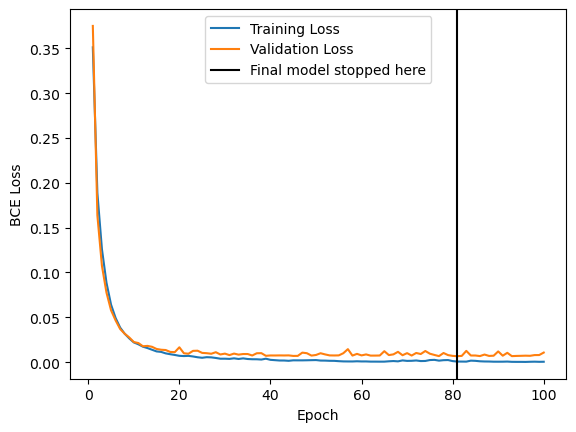

In [9]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

Test AUROC: 0.9991


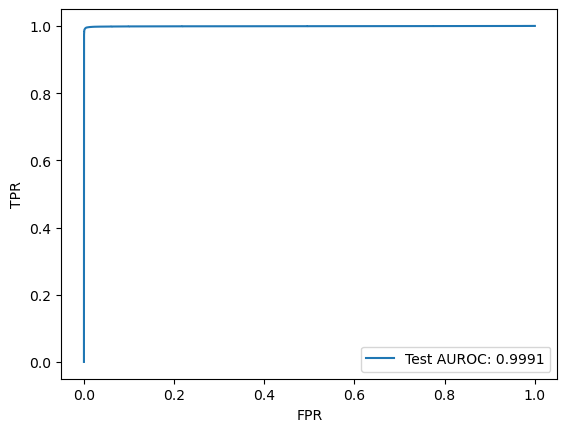

In [10]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

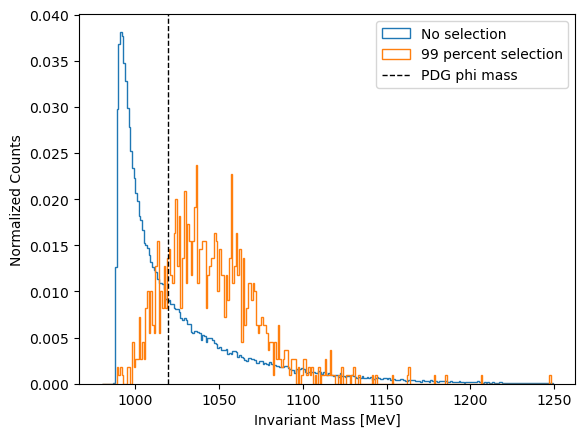

In [11]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [12]:
# Store the pretrained classifier labels
df_test["Class_pre"] = test_pred

# Save the pretrained classifier model
torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/pretrained_FakeGen_classifier_2019_pass2_run"+str(run)+"_scaled.pt")

# Setup the adversary model

## Initialize model, objective function, and optimizer

In [13]:
adv = mytools.Adversary_small(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-3)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=1.0)


## Setup dataloaders

In [14]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train), (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val), (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float() )
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relavent for testing
test_adv_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_test))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)

## Pre-train the adversary leaving classifier weights fixed

In [15]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored


Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)

print("Done!")

Epoch 1
-------------------------------
Training loss: 2.444813
Validation loss: 2.316012 

Epoch 2
-------------------------------
Training loss: 2.314730
Validation loss: 2.308269 

Epoch 3
-------------------------------
Training loss: 2.304351
Validation loss: 2.304787 

Epoch 4
-------------------------------
Training loss: 2.303773
Validation loss: 2.303017 

Epoch 5
-------------------------------
Training loss: 2.303309
Validation loss: 2.305836 

Epoch 6
-------------------------------
Training loss: 2.304363
Validation loss: 2.303368 

Epoch 7
-------------------------------
Training loss: 2.302911
Validation loss: 2.302722 

Epoch 8
-------------------------------
Training loss: 2.302646
Validation loss: 2.301932 

Epoch 9
-------------------------------
Training loss: 2.303629
Validation loss: 2.302606 

Epoch 10
-------------------------------
Training loss: 2.303254
Validation loss: 2.303010 

Epoch 11
-------------------------------
Training loss: 2.302217
Validation los

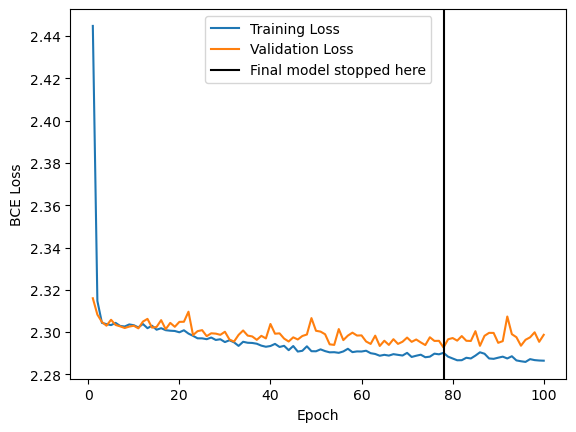

In [16]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

# Train full adverserial neural network

# Setup dataloaders

In [17]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train),  (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val),  (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float())
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [18]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss(reduction='none') # returns loss per sample so we can weight it

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    sample_losses2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    # Weighted mean loss over non-zero weights
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [19]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-4,betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=1e-3,betas=(0.9, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

Epoch 1
-------------------------------
Classifier training loss: -11.703120
Adversary training loss: 2.353051
Classifier validation loss: -12.120690
Adversary validation loss: 2.431643
Diff score: 4.567626


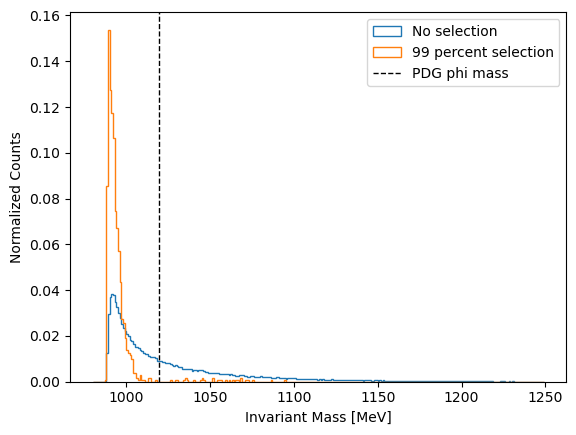

Epoch 2
-------------------------------
Classifier training loss: -11.218765
Adversary training loss: 2.279729
Classifier validation loss: -10.913287
Adversary validation loss: 2.227801
Diff score: 3.970447


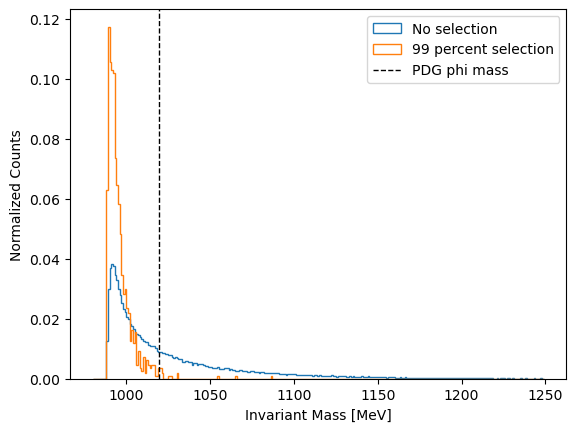

Epoch 3
-------------------------------
Classifier training loss: -11.126652
Adversary training loss: 2.255850
Classifier validation loss: -11.375220
Adversary validation loss: 2.291203
Diff score: 1.053458


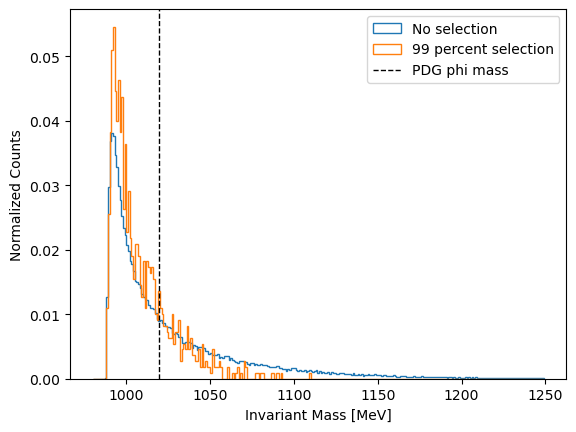

Epoch 4
-------------------------------
Classifier training loss: -11.458401
Adversary training loss: 2.300566
Classifier validation loss: -11.443349
Adversary validation loss: 2.294436
Diff score: 0.878883


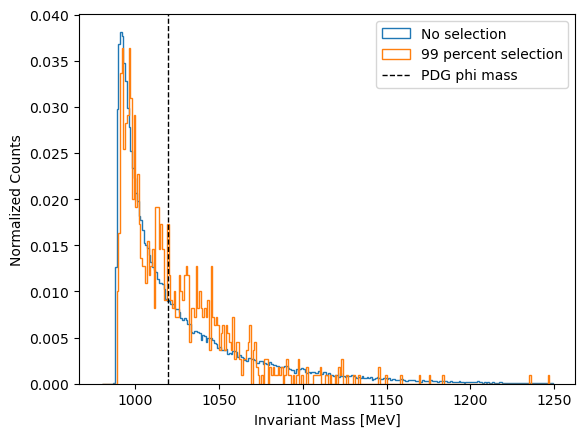

Epoch 5
-------------------------------
Classifier training loss: -11.481572
Adversary training loss: 2.300182
Classifier validation loss: -11.496395
Adversary validation loss: 2.303696
Diff score: 0.817928


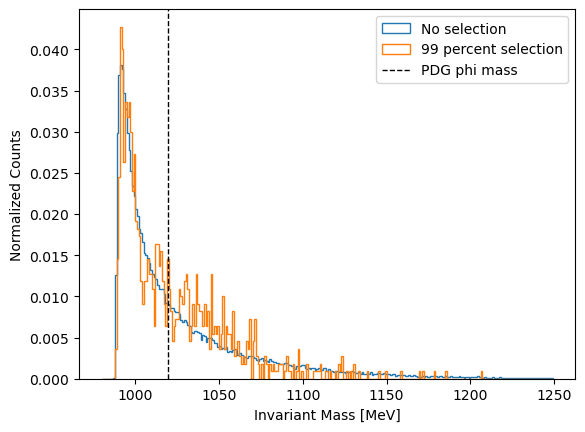

Epoch 6
-------------------------------
Classifier training loss: -11.494030
Adversary training loss: 2.301821
Classifier validation loss: -11.525319
Adversary validation loss: 2.308172
Diff score: 0.894783


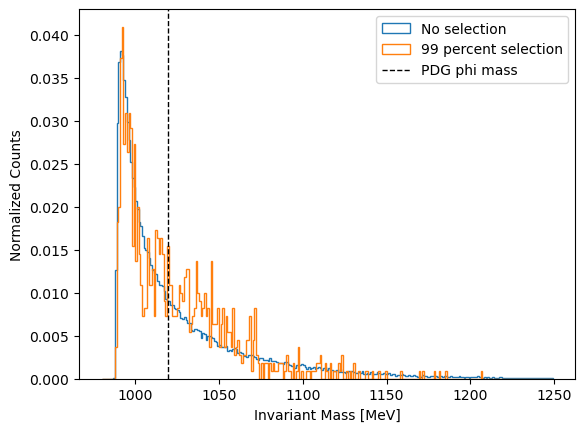

Epoch 7
-------------------------------
Classifier training loss: -11.509542
Adversary training loss: 2.303132
Classifier validation loss: -11.514651
Adversary validation loss: 2.305184
Diff score: 1.091806


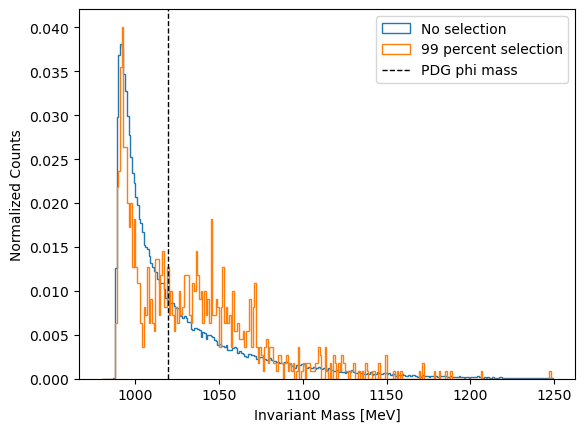

Epoch 8
-------------------------------
Classifier training loss: -11.512062
Adversary training loss: 2.304236
Classifier validation loss: -11.529488
Adversary validation loss: 2.308199
Diff score: 1.359209


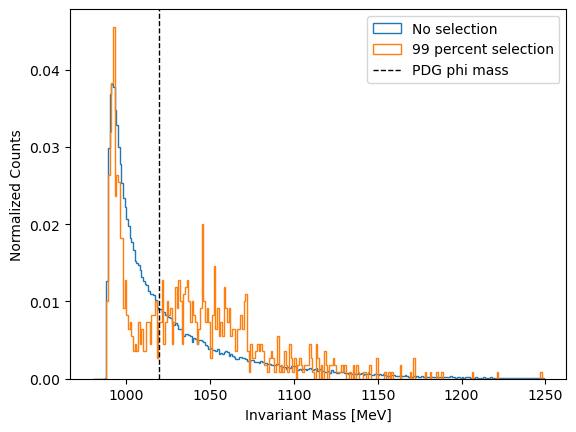

Epoch 9
-------------------------------
Classifier training loss: -11.519621
Adversary training loss: 2.304724
Classifier validation loss: -11.551366
Adversary validation loss: 2.312093
Diff score: 1.356439


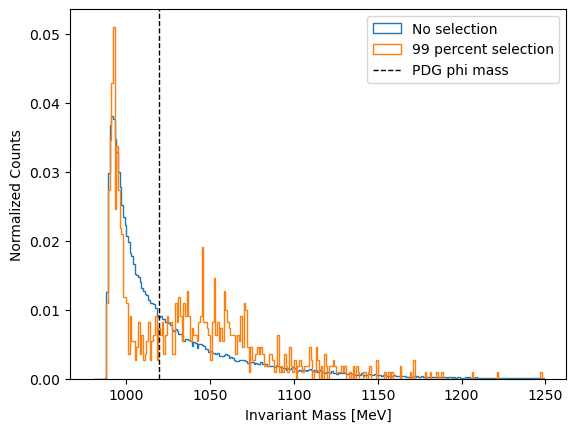

Epoch 10
-------------------------------
Classifier training loss: -11.519878
Adversary training loss: 2.304143
Classifier validation loss: -11.534204
Adversary validation loss: 2.308717
Diff score: 1.280077


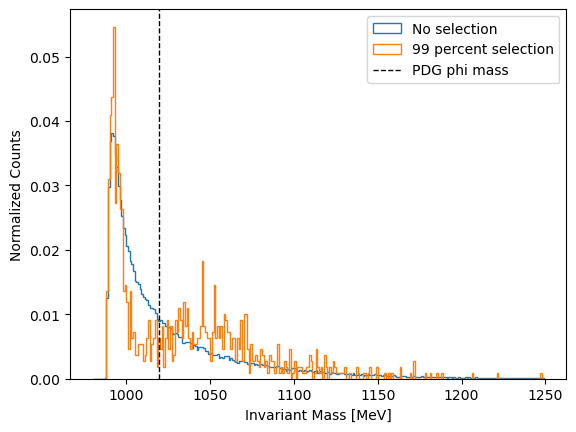

Epoch 11
-------------------------------
Classifier training loss: -11.512211
Adversary training loss: 2.303347
Classifier validation loss: -11.525517
Adversary validation loss: 2.306824
Diff score: 1.256174


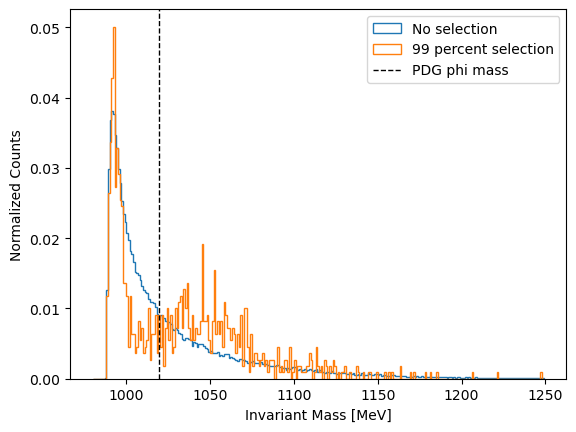

Epoch 12
-------------------------------
Classifier training loss: -11.517879
Adversary training loss: 2.303949
Classifier validation loss: -11.542269
Adversary validation loss: 2.310199
Diff score: 1.130523


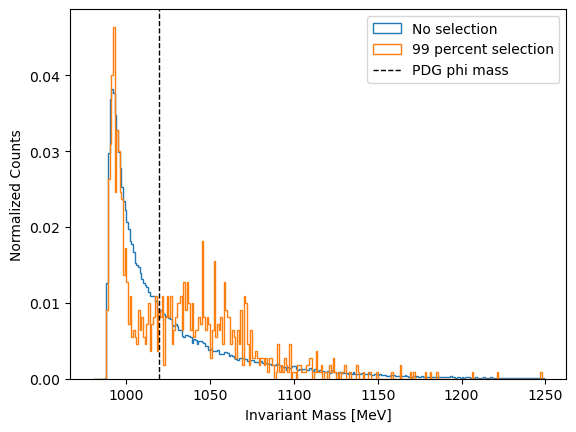

Epoch 13
-------------------------------
Classifier training loss: -11.517332
Adversary training loss: 2.304373
Classifier validation loss: -11.521147
Adversary validation loss: 2.305822
Diff score: 1.093227


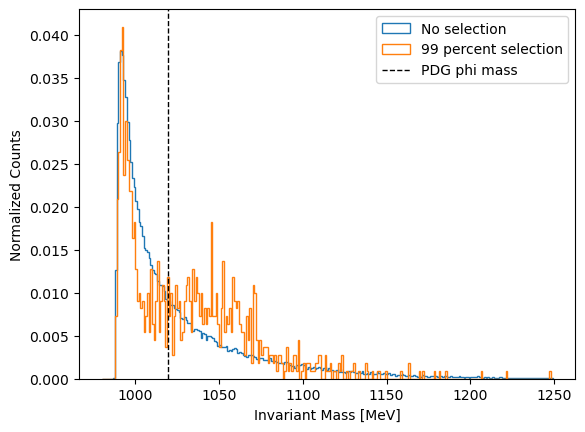

Epoch 14
-------------------------------
Classifier training loss: -11.522324
Adversary training loss: 2.304949
Classifier validation loss: -11.520928
Adversary validation loss: 2.305684
Diff score: 1.004686


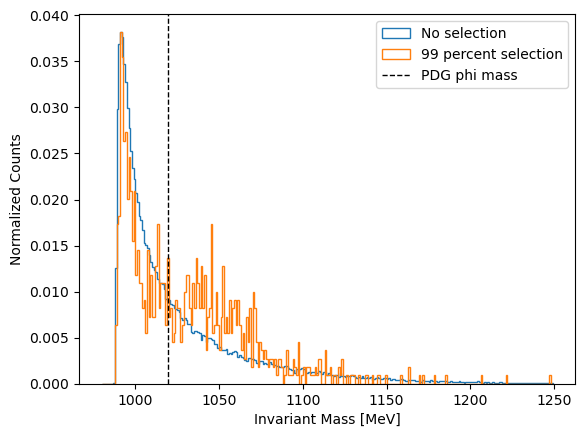

Epoch 15
-------------------------------
Classifier training loss: -11.520049
Adversary training loss: 2.304965
Classifier validation loss: -11.527508
Adversary validation loss: 2.307165
Diff score: 1.023224


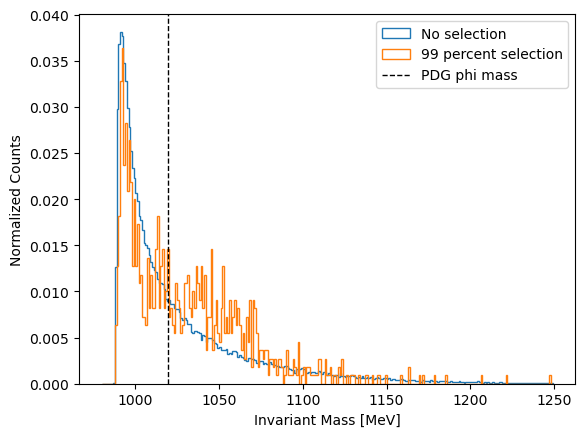

Epoch 16
-------------------------------
Classifier training loss: -11.521356
Adversary training loss: 2.304448
Classifier validation loss: -11.538240
Adversary validation loss: 2.309098
Diff score: 0.935666


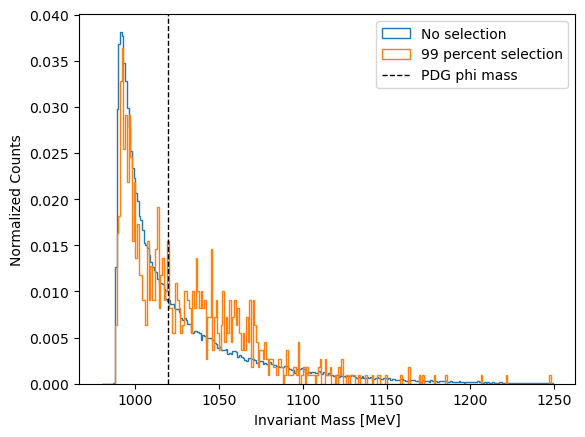

Epoch 17
-------------------------------
Classifier training loss: -11.524827
Adversary training loss: 2.304919
Classifier validation loss: -11.524934
Adversary validation loss: 2.306455
Diff score: 0.943354


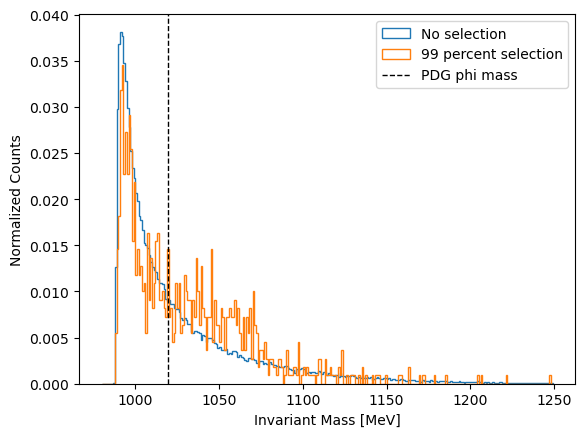

Epoch 18
-------------------------------
Classifier training loss: -11.517246
Adversary training loss: 2.304669
Classifier validation loss: -11.519038
Adversary validation loss: 2.305439
Diff score: 0.881882


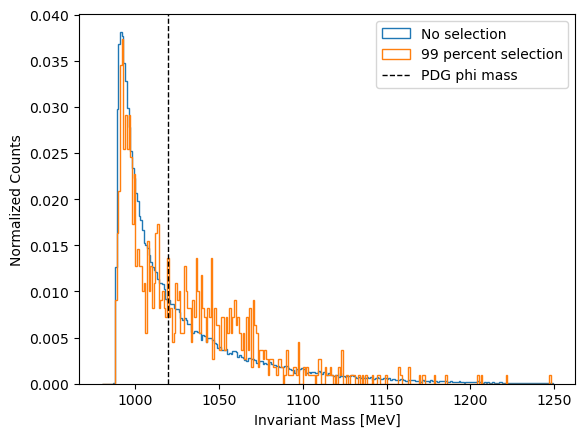

Epoch 19
-------------------------------
Classifier training loss: -11.522892
Adversary training loss: 2.305051
Classifier validation loss: -11.528079
Adversary validation loss: 2.307097
Diff score: 0.928301


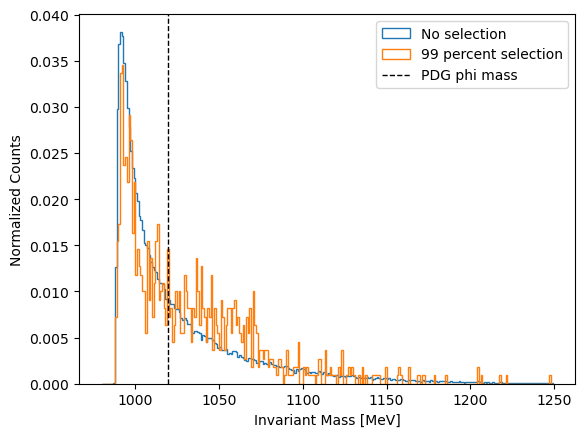

Epoch 20
-------------------------------
Classifier training loss: -11.518624
Adversary training loss: 2.304386
Classifier validation loss: -11.538661
Adversary validation loss: 2.309301
Diff score: 1.011829


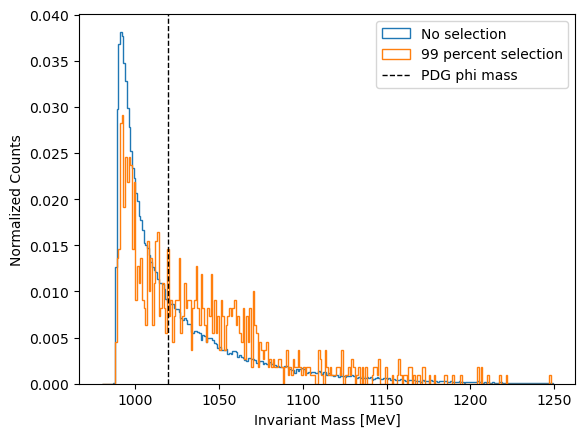

Epoch 21
-------------------------------
Classifier training loss: -11.520710
Adversary training loss: 2.304708
Classifier validation loss: -11.522921
Adversary validation loss: 2.306039
Diff score: 0.863538


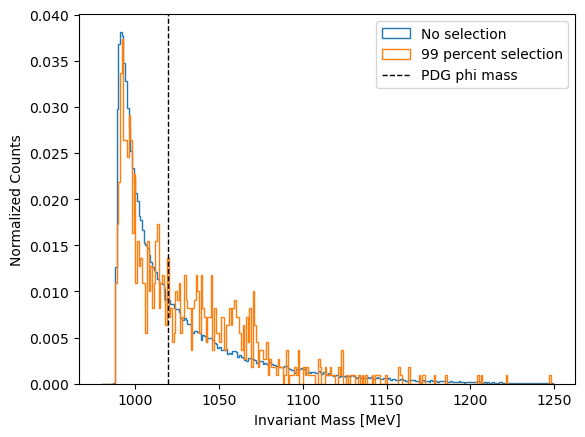

Epoch 22
-------------------------------
Classifier training loss: -11.520975
Adversary training loss: 2.304473
Classifier validation loss: -11.519512
Adversary validation loss: 2.305452
Diff score: 1.182421


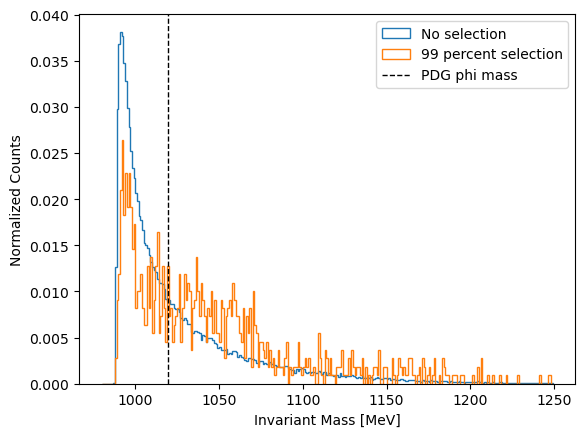

Epoch 23
-------------------------------
Classifier training loss: -11.519431
Adversary training loss: 2.304891
Classifier validation loss: -11.542136
Adversary validation loss: 2.309872
Diff score: 0.902954


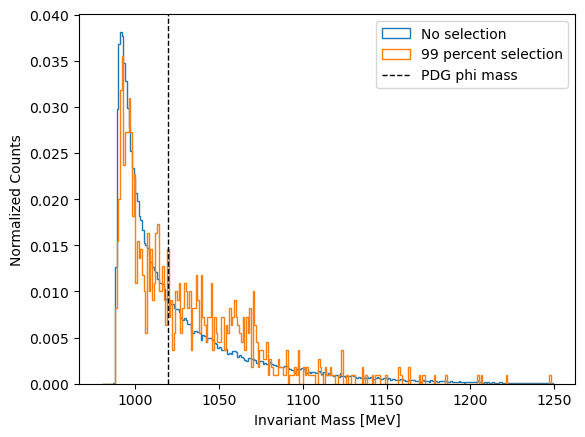

Epoch 24
-------------------------------
Classifier training loss: -11.514556
Adversary training loss: 2.303767
Classifier validation loss: -11.516525
Adversary validation loss: 2.304991
Diff score: 0.946442


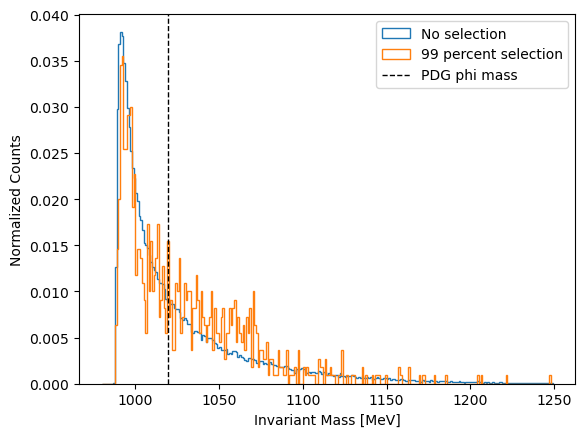

Epoch 25
-------------------------------
Classifier training loss: -11.518473
Adversary training loss: 2.303787
Classifier validation loss: -11.533011
Adversary validation loss: 2.308442
Diff score: 1.159295


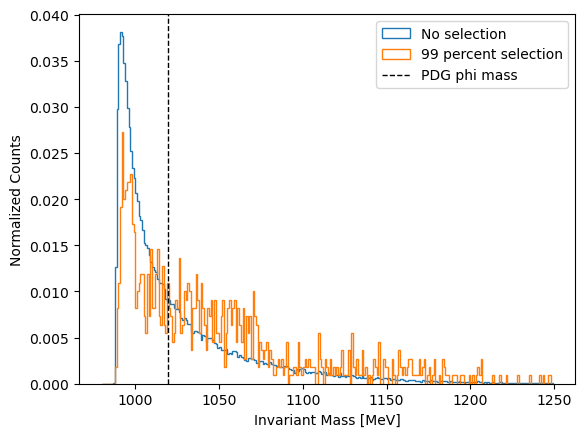

Epoch 26
-------------------------------
Classifier training loss: -11.517247
Adversary training loss: 2.303829
Classifier validation loss: -11.496154
Adversary validation loss: 2.300782
Diff score: 0.804922


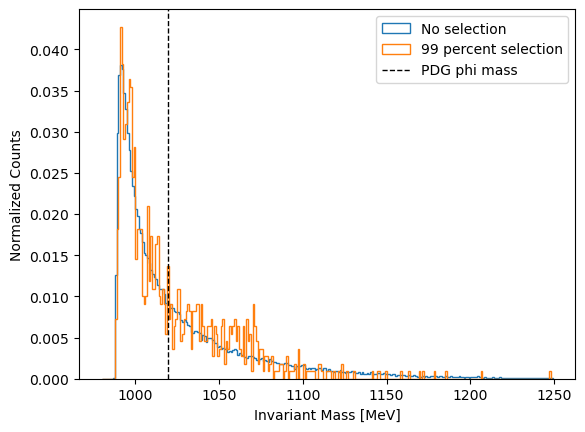

Epoch 27
-------------------------------
Classifier training loss: -11.516483
Adversary training loss: 2.304796
Classifier validation loss: -11.538994
Adversary validation loss: 2.309244
Diff score: 0.907691


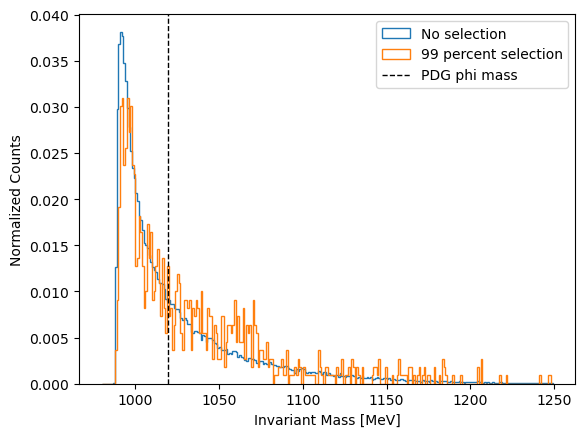

Epoch 28
-------------------------------
Classifier training loss: -11.491876
Adversary training loss: 2.298945
Classifier validation loss: -11.504980
Adversary validation loss: 2.302539
Diff score: 0.754078


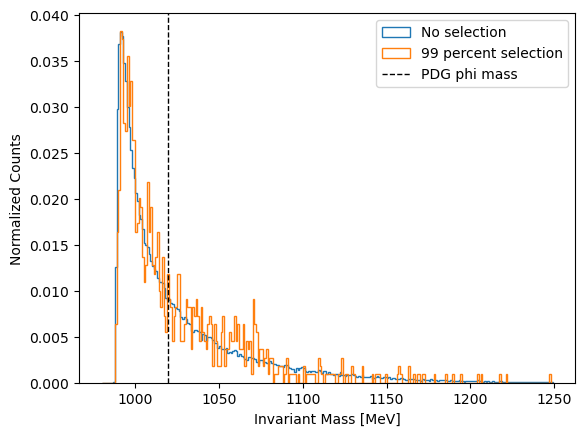

Epoch 29
-------------------------------
Classifier training loss: -11.500215
Adversary training loss: 2.300879
Classifier validation loss: -11.518066
Adversary validation loss: 2.305240
Diff score: 0.881456


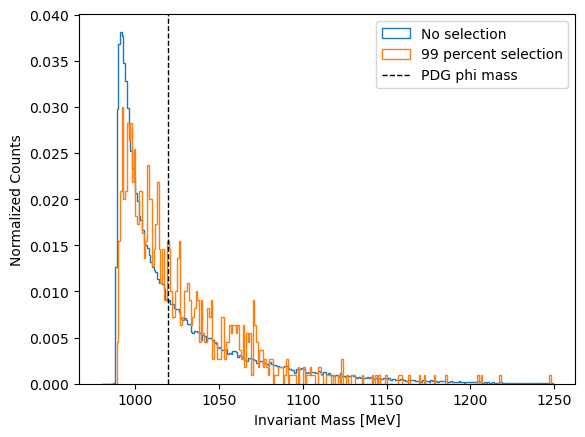

Epoch 30
-------------------------------
Classifier training loss: -11.512520
Adversary training loss: 2.304083
Classifier validation loss: -11.518321
Adversary validation loss: 2.305348
Diff score: 1.519515


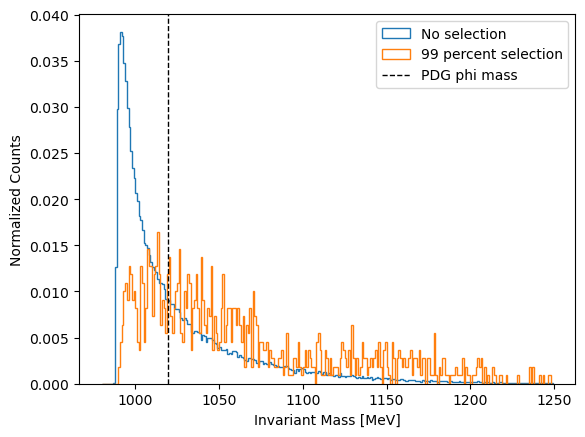

Epoch 31
-------------------------------
Classifier training loss: -11.510120
Adversary training loss: 2.302628
Classifier validation loss: -11.525580
Adversary validation loss: 2.306645
Diff score: 1.263032


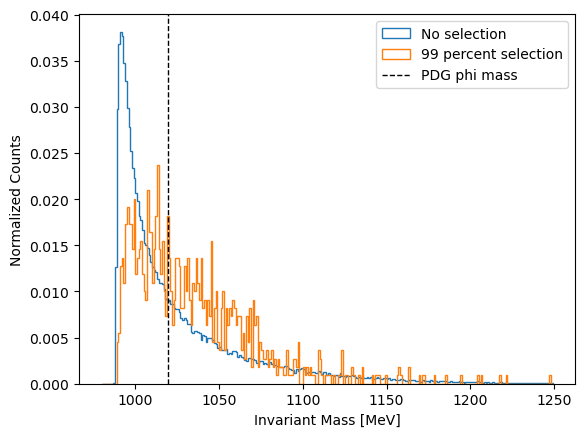

Epoch 32
-------------------------------
Classifier training loss: -11.508411
Adversary training loss: 2.302380
Classifier validation loss: -11.513599
Adversary validation loss: 2.304242
Diff score: 1.226564


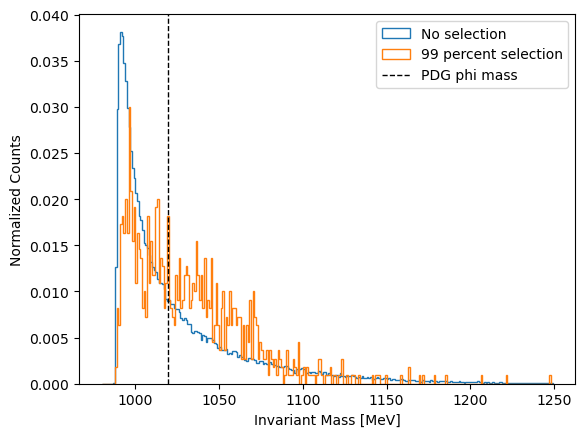

Epoch 33
-------------------------------
Classifier training loss: -11.510045
Adversary training loss: 2.302713
Classifier validation loss: -11.524067
Adversary validation loss: 2.306553
Diff score: 1.132303


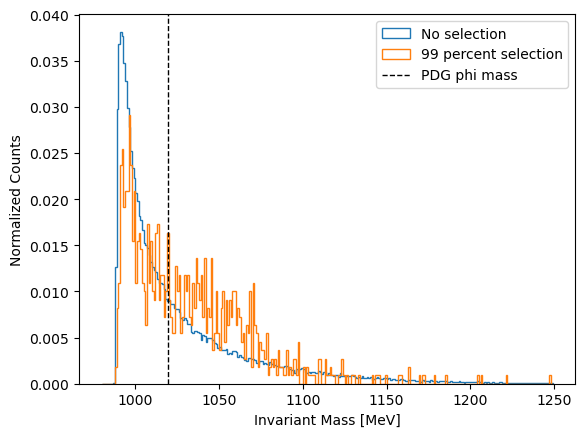

Epoch 34
-------------------------------
Classifier training loss: -11.514120
Adversary training loss: 2.303650
Classifier validation loss: -11.524417
Adversary validation loss: 2.306369
Diff score: 0.794390


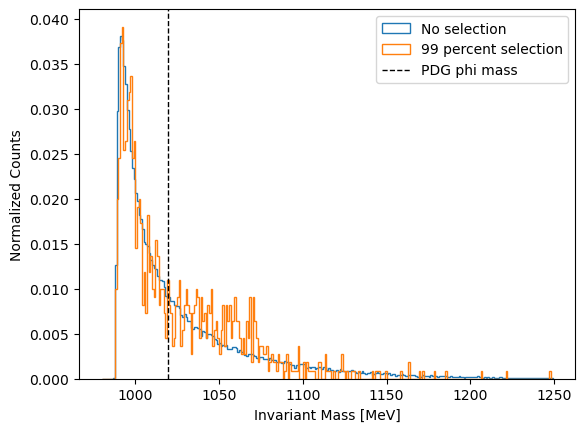

Epoch 35
-------------------------------
Classifier training loss: -11.513064
Adversary training loss: 2.303498
Classifier validation loss: -11.519805
Adversary validation loss: 2.305531
Diff score: 0.801963


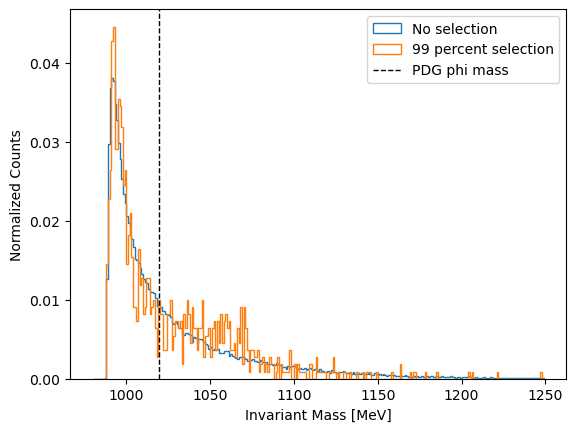

Epoch 36
-------------------------------
Classifier training loss: -11.516021
Adversary training loss: 2.304124
Classifier validation loss: -11.542159
Adversary validation loss: 2.310107
Diff score: 1.085645


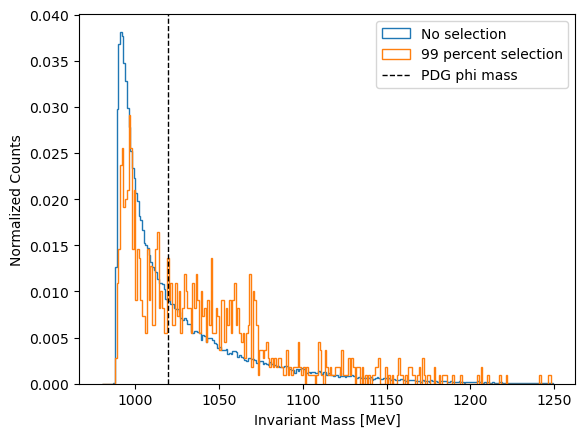

Epoch 37
-------------------------------
Classifier training loss: -11.518143
Adversary training loss: 2.304403
Classifier validation loss: -11.525389
Adversary validation loss: 2.306531
Diff score: 1.247020


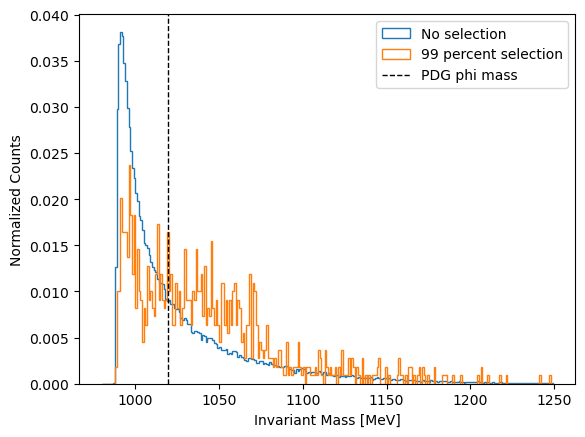

Epoch 38
-------------------------------
Classifier training loss: -11.516567
Adversary training loss: 2.303870
Classifier validation loss: -11.536094
Adversary validation loss: 2.308651
Diff score: 1.392611


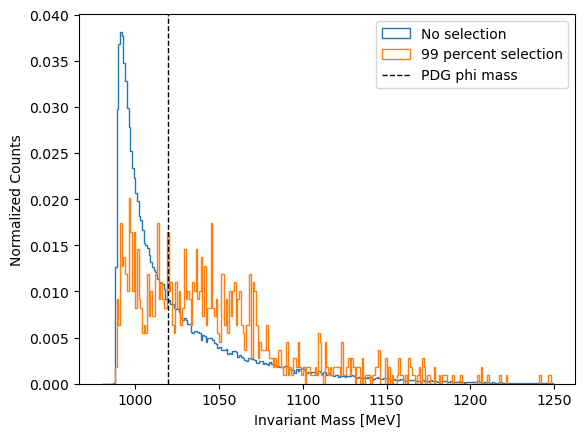

Epoch 39
-------------------------------
Classifier training loss: -11.514969
Adversary training loss: 2.303919
Classifier validation loss: -11.510847
Adversary validation loss: 2.304304
Diff score: 1.376185


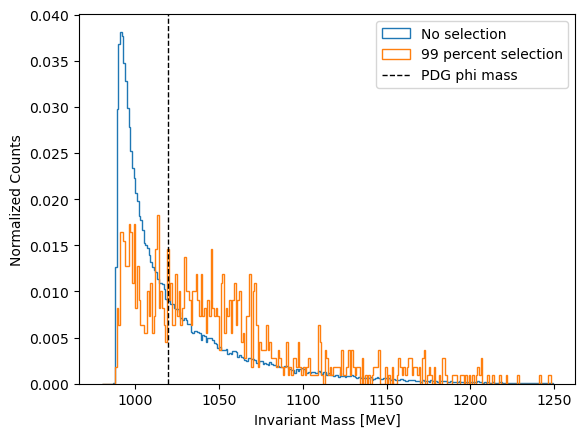

Epoch 40
-------------------------------
Classifier training loss: -11.511363
Adversary training loss: 2.302742
Classifier validation loss: -11.526312
Adversary validation loss: 2.306714
Diff score: 0.787299


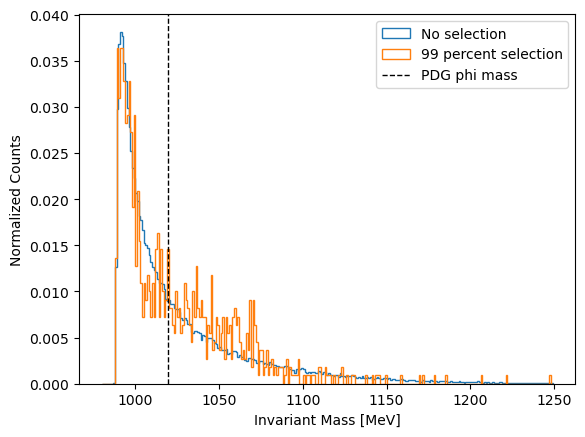

Epoch 41
-------------------------------
Classifier training loss: -11.517990
Adversary training loss: 2.304739
Classifier validation loss: -11.522184
Adversary validation loss: 2.305850
Diff score: 0.750072


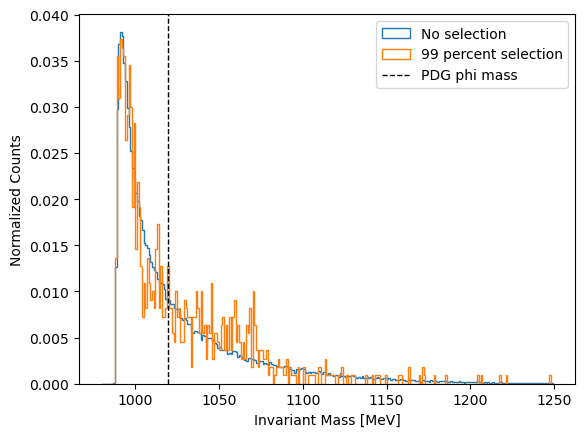

Epoch 42
-------------------------------
Classifier training loss: -11.503833
Adversary training loss: 2.301671
Classifier validation loss: -11.518055
Adversary validation loss: 2.305093
Diff score: 0.716407


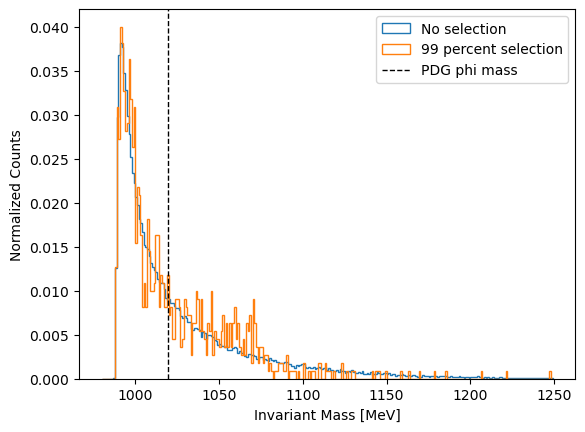

Epoch 43
-------------------------------
Classifier training loss: -11.517040
Adversary training loss: 2.303907
Classifier validation loss: -11.524199
Adversary validation loss: 2.306823
Diff score: 0.979356


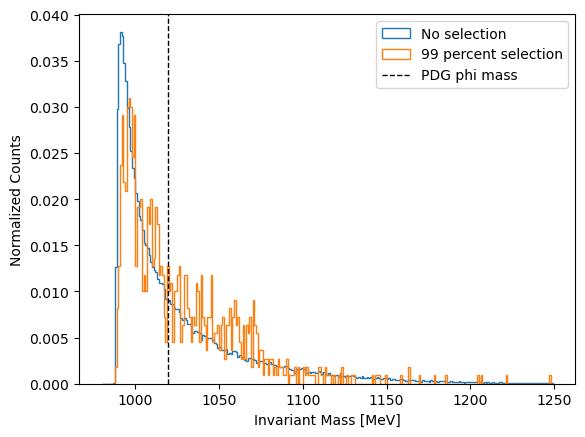

Epoch 44
-------------------------------
Classifier training loss: -11.515221
Adversary training loss: 2.303559
Classifier validation loss: -11.525749
Adversary validation loss: 2.306585
Diff score: 1.300617


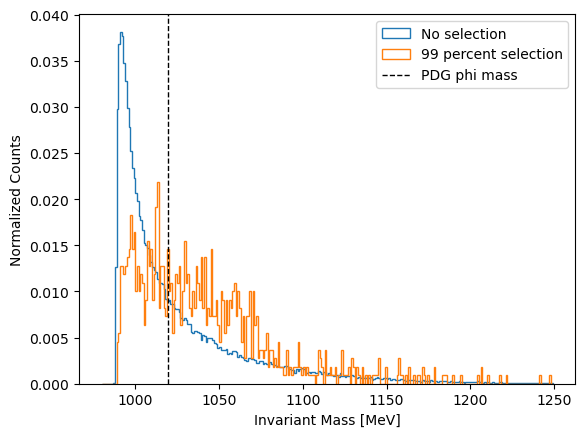

Epoch 45
-------------------------------
Classifier training loss: -11.500416
Adversary training loss: 2.301545
Classifier validation loss: -11.500481
Adversary validation loss: 2.301538
Diff score: 1.486091


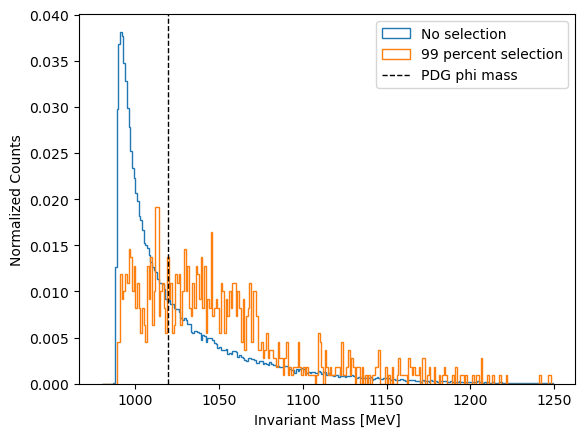

Epoch 46
-------------------------------
Classifier training loss: -11.511526
Adversary training loss: 2.303075
Classifier validation loss: -11.520644
Adversary validation loss: 2.305627
Diff score: 0.876455


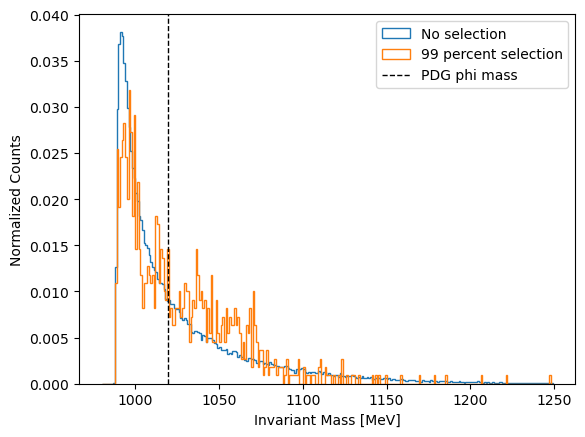

Epoch 47
-------------------------------
Classifier training loss: -11.508860
Adversary training loss: 2.302902
Classifier validation loss: -11.518899
Adversary validation loss: 2.305281
Diff score: 0.825405


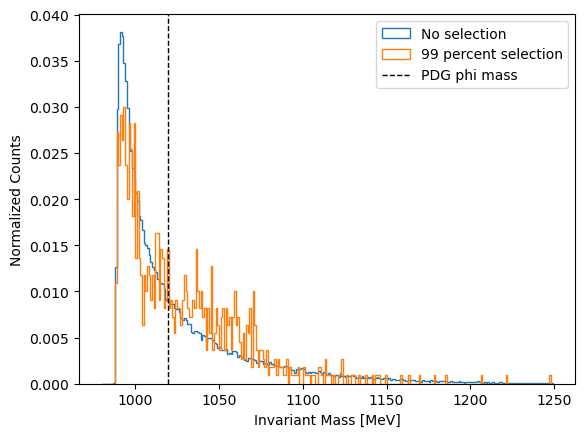

Epoch 48
-------------------------------
Classifier training loss: -11.502516
Adversary training loss: 2.301241
Classifier validation loss: -11.520325
Adversary validation loss: 2.305428
Diff score: 1.021265


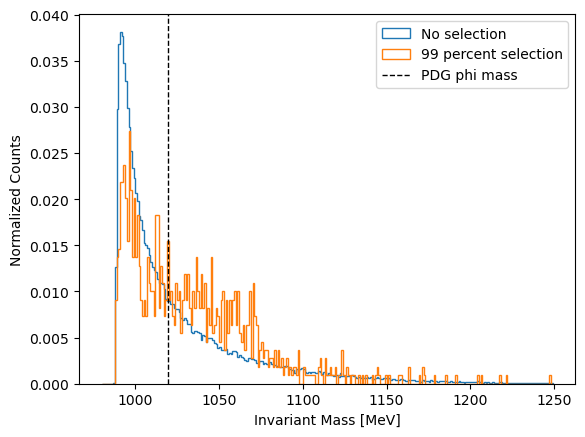

Epoch 49
-------------------------------
Classifier training loss: -11.517444
Adversary training loss: 2.303961
Classifier validation loss: -11.518996
Adversary validation loss: 2.305234
Diff score: 1.132838


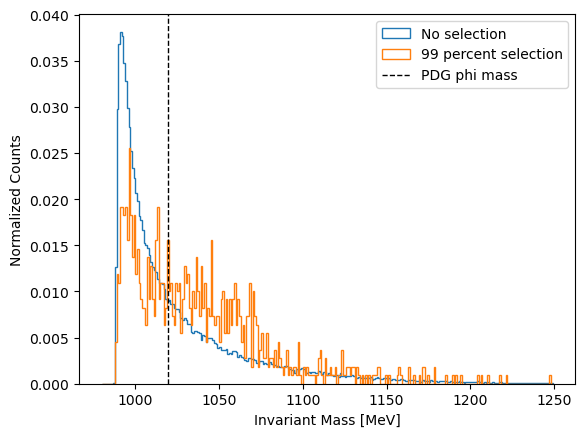

Epoch 50
-------------------------------
Classifier training loss: -11.512133
Adversary training loss: 2.303206
Classifier validation loss: -11.520598
Adversary validation loss: 2.305473
Diff score: 1.342370


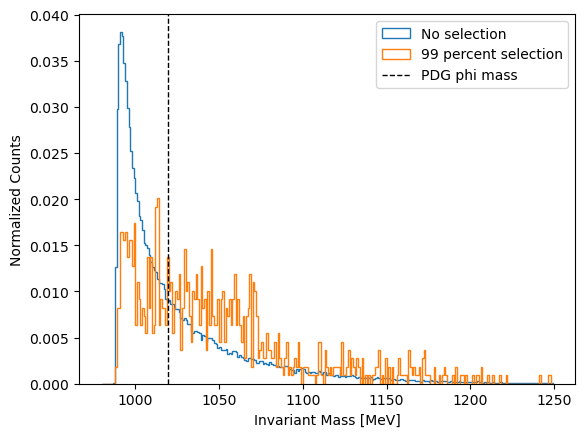

Done!


In [20]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = mytools.train_full_orig(train_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, 8, device, grad_clip = False)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)

    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = mytools.validate_full(val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Get the diff_score
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
    per = np.percentile(df_bkg['Class_adv'],99)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000*df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2) )

    print(f"Diff score: {diff_scores[-1]:>7f}")

    plt.figure()
    plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
    plt.hist(1000*df_cut.InvM, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
    plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
    plt.xlabel('Invariant Mass [MeV]')
    plt.ylabel('Normalized Counts')
    plt.legend()
    plt.show()

    # Keep a running copy of the model with the lowest loss
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

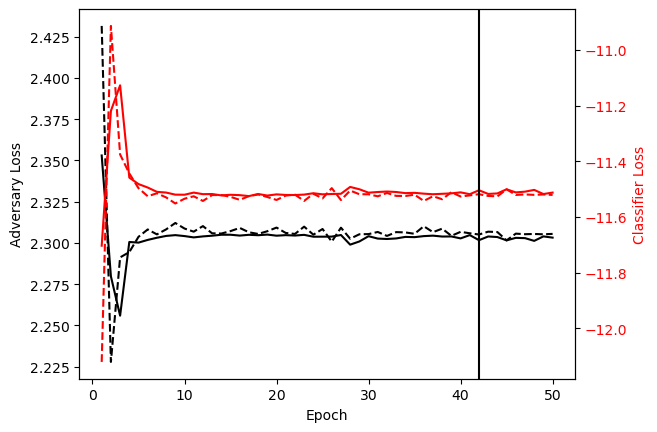

In [21]:
# Training Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



Text(0.5, 0, 'Epoch')

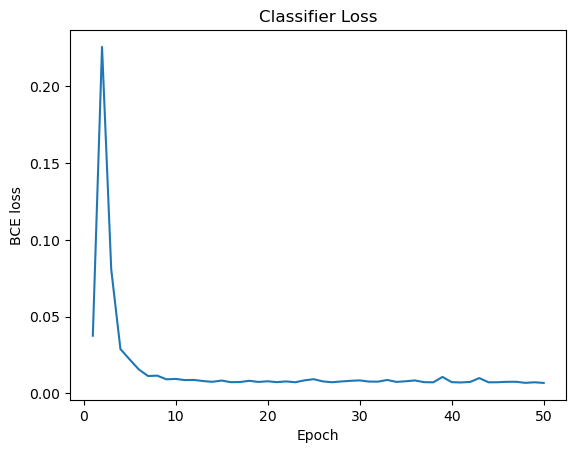

In [22]:
Validation_losses_clas+lambda_*Validation_losses_adv

plt.title("Classifier Loss")
plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_clas+lambda_*Validation_losses_adv)
plt.ylabel("BCE loss")
plt.xlabel('Epoch')

## Test adversarially trained models

Test AUROC: 0.9987


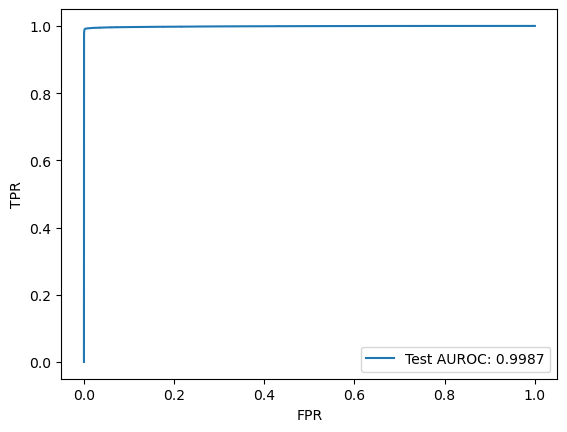

In [23]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

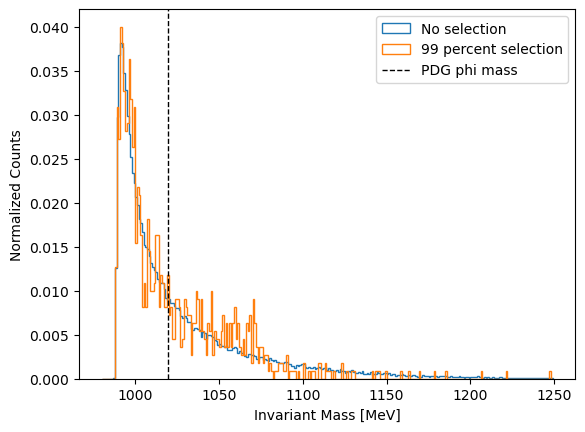

In [24]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [25]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean( np.abs( N2/np.sum(N) - M2/np.sum(M) ) / np.sqrt( ( np.sqrt(N2)/np.sum(N) )**2 + ( np.sqrt(M2)/np.sum(M) )**2 ) )

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.7164068175635779
1.825


Test AUROC: 0.9989


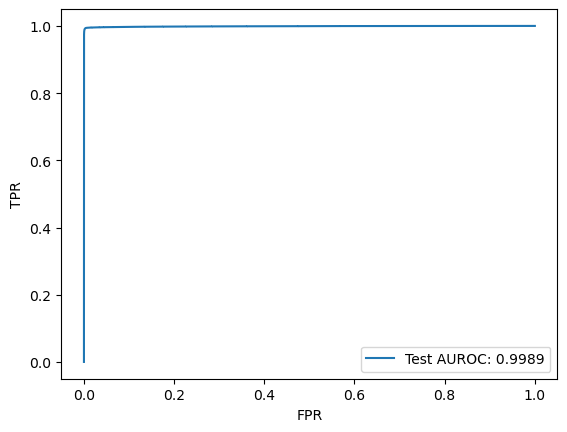

In [26]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

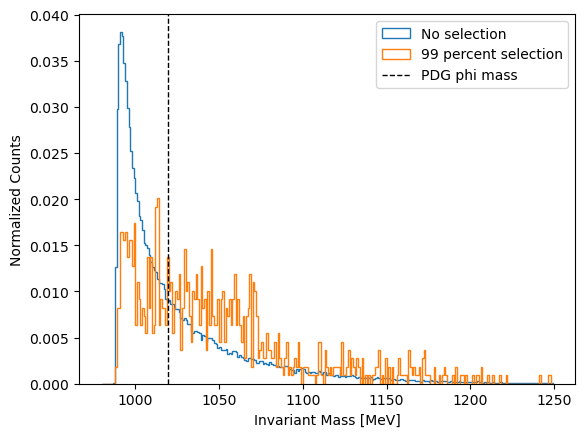

In [27]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [28]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

1.2273836519057084
1.7793427230046948


In [29]:
# Save the adversarially trained models
torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/FakeGen_classifier_adv_2019_pass2_run"+str(run)+"_scaled.pt")
torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/FakeGen_adversary_adv_2019_pass2_run"+str(run)+"_scaled.pt")
